In [15]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-darkgrid")


In [16]:
csv_path = "D:\\DS Assignment\\Timeseries\\Timeseries\\exchange_rate.csv"

df = pd.read_csv(
    csv_path,
    parse_dates=["date"],
    dayfirst=True
)

print(df.head(3))
print(df.tail(3))
print(df.info())

df = df[["date", "Ex_rate"]].dropna()
df = df.sort_values("date").set_index("date")

df = df.asfreq("D")  
print("Date range:", df.index.min(), "->", df.index.max())
print("Missing after asfreq:", df["Ex_rate"].isna().sum())


        date  Ex_rate
0 1990-01-01   0.7855
1 1990-01-02   0.7818
2 1990-01-03   0.7867
           date   Ex_rate
7585 2010-10-08  0.723197
7586 2010-10-09  0.720825
7587 2010-10-10  0.720825
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   date     7588 non-null   datetime64[ns]
 1   Ex_rate  7588 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 118.7 KB
None
Date range: 1990-01-01 00:00:00 -> 2010-10-10 00:00:00
Missing after asfreq: 0


Missing after interpolation: 0


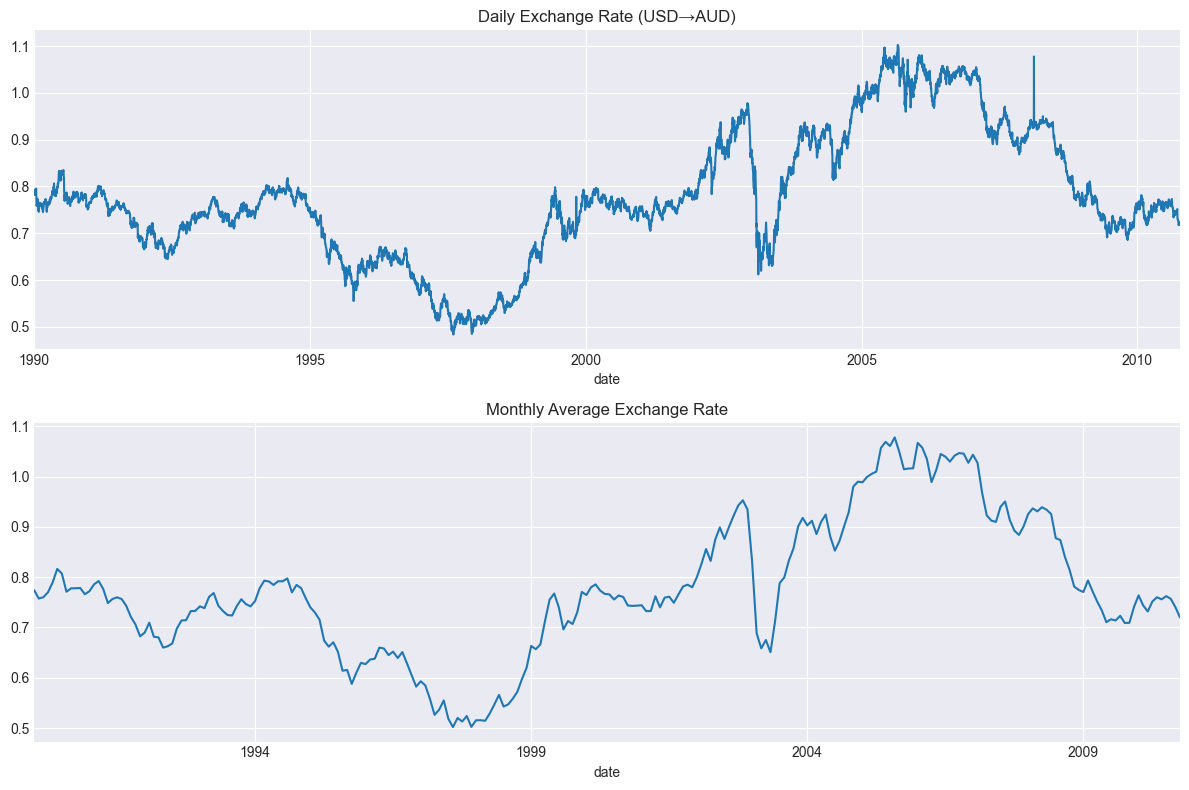

In [17]:
if df["Ex_rate"].isna().sum() > 0:
    df["Ex_rate"] = df["Ex_rate"].ffill().bfill()

print("Missing after interpolation:", df["Ex_rate"].isna().sum())

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)
df["Ex_rate"].plot(ax=axes[0], title="Daily Exchange Rate (USD→AUD)")
df["Ex_rate"].resample("M").mean().plot(ax=axes[1], title="Monthly Average Exchange Rate")
plt.tight_layout()
plt.show()


In [18]:
h = 365
train = df.iloc[:-h].copy()
test  = df.iloc[-h:].copy()

print("Train range:", train.index.min(), "->", train.index.max(), "len:", len(train))
print("Test  range:", test.index.min(),  "->", test.index.max(),  "len:", len(test))


Train range: 1990-01-01 00:00:00 -> 2009-10-10 00:00:00 len: 7223
Test  range: 2009-10-11 00:00:00 -> 2010-10-10 00:00:00 len: 365


In [19]:
adf_stat, pval, *_ = adfuller(train["Ex_rate"].dropna())
print(f"ADF stat: {adf_stat:.3f}, p-value: {pval:.4f}")

train_diff = train["Ex_rate"].diff().dropna()
adf_stat_d1, pval_d1, *_ = adfuller(train_diff)
print(f"ADF on 1st diff: stat={adf_stat_d1:.3f}, p={pval_d1:.4f}")


ADF stat: -1.607, p-value: 0.4800
ADF on 1st diff: stat=-97.069, p=0.0000


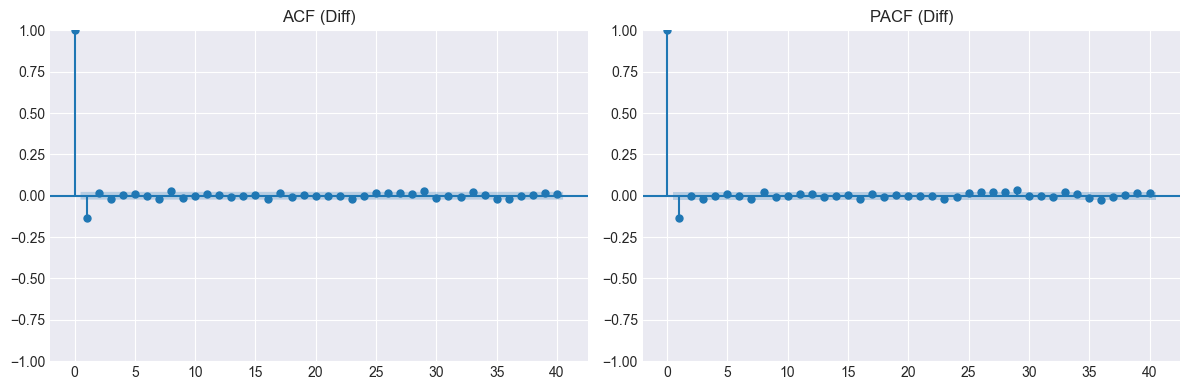

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(train_diff, ax=axes[0], lags=40, title="ACF (Diff)")
plot_pacf(train_diff, ax=axes[1], lags=40, title="PACF (Diff)", method="ywm")
plt.tight_layout()
plt.show()


In [21]:
import itertools

def try_arima_grid(y, p_vals, d_vals, q_vals):
    best = {"aic": np.inf, "order": None, "model": None}
    for p, d, q in itertools.product(p_vals, d_vals, q_vals):
        try:
            model = ARIMA(y, order=(p, d, q)).fit()
            if model.aic < best["aic"]:
                best = {"aic": model.aic, "order": (p, d, q), "model": model}
        except Exception:
            continue
    return best

p_vals = range(0, 4)
d_vals = [0, 1]
q_vals = range(0, 4)

best_arima = try_arima_grid(train["Ex_rate"], p_vals, d_vals, q_vals)
print("Best ARIMA order:", best_arima["order"], "AIC:", best_arima["aic"])
arima_model = best_arima["model"]
print(arima_model.summary())


Best ARIMA order: (3, 0, 3) AIC: -53258.85763597495
                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7223
Model:                 ARIMA(3, 0, 3)   Log Likelihood               26637.429
Date:                Fri, 06 Mar 2026   AIC                         -53258.858
Time:                        01:46:00   BIC                         -53203.777
Sample:                    01-01-1990   HQIC                        -53239.908
                         - 10-10-2009                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7787      0.096      8.128      0.000       0.591       0.966
ar.L1          0.3606      0.097      3.726      0.000       0.171       0.550


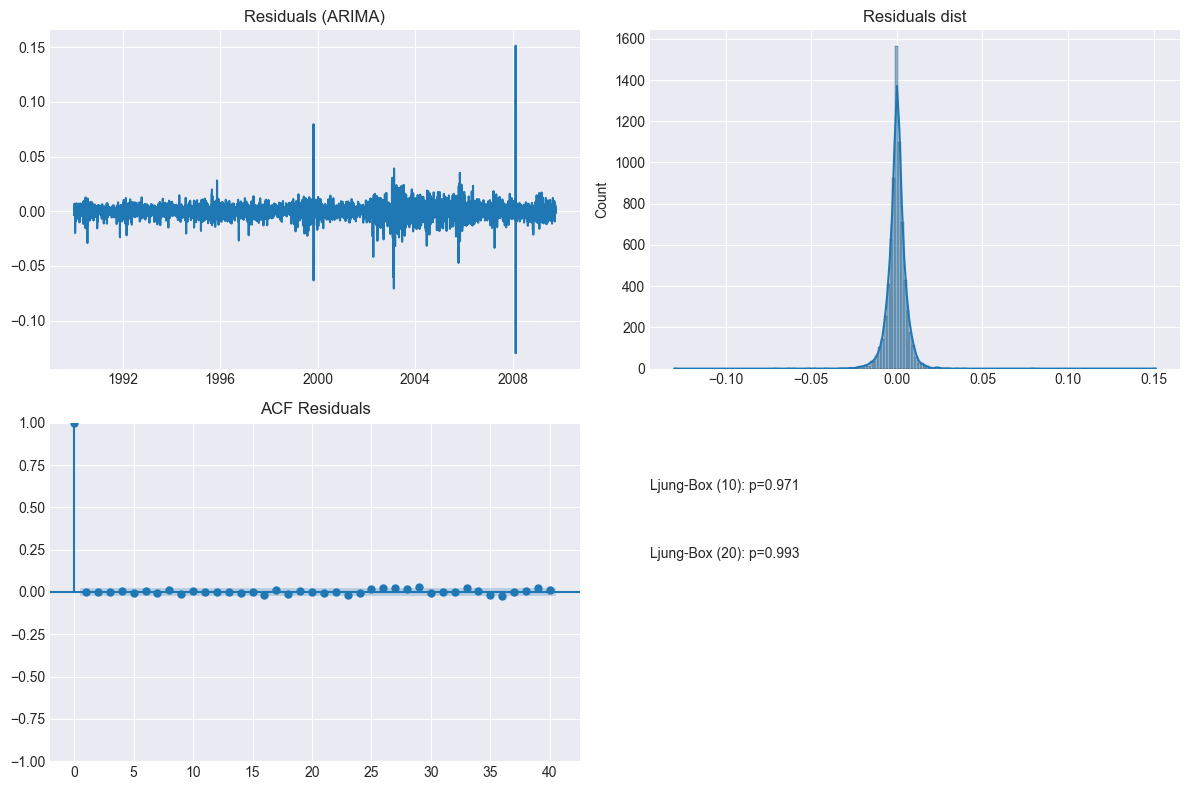

In [22]:
resid = arima_model.resid  


fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(resid)
axes[0, 0].set_title("Residuals (ARIMA)")

import seaborn as sns
sns.histplot(resid, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Residuals dist")

from statsmodels.graphics.tsaplots import plot_acf
plot_acf(resid, ax=axes[1, 0], lags=40, title="ACF Residuals")

from statsmodels.stats.diagnostic import acorr_ljungbox
lb = acorr_ljungbox(resid, lags=[10, 20], return_df=True)

axes[1, 1].axis('off')
axes[1, 1].text(0, 0.8, f"Ljung-Box (10): p={lb['lb_pvalue'].iloc[0]:.3f}")
axes[1, 1].text(0, 0.6, f"Ljung-Box (20): p={lb['lb_pvalue'].iloc[1]:.3f}")

plt.tight_layout()
plt.show()


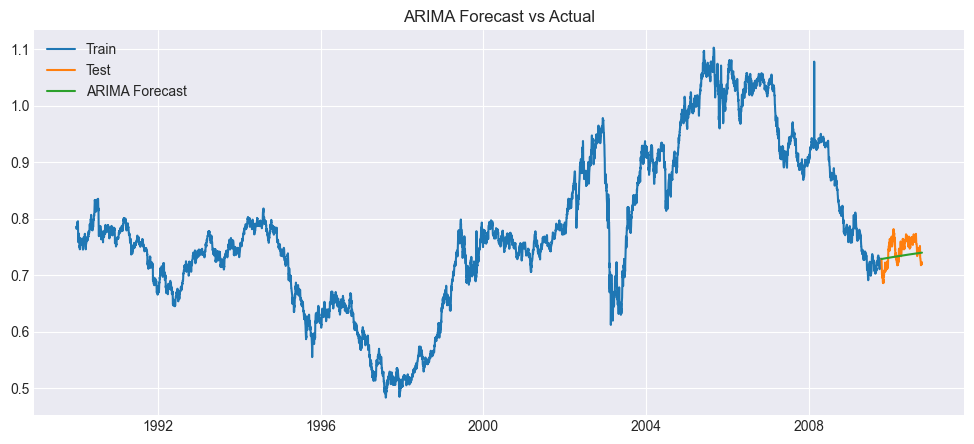

In [23]:
n_forecast = len(test)
arima_forecast = arima_model.forecast(steps=n_forecast)
arima_forecast = pd.Series(arima_forecast, index=test.index, name="ARIMA_Forecast")


plt.figure(figsize=(12,5))
plt.plot(train["Ex_rate"], label="Train")
plt.plot(test["Ex_rate"], label="Test")
plt.plot(arima_forecast, label="ARIMA Forecast")
plt.title("ARIMA Forecast vs Actual")
plt.legend()
plt.show()


In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

try:
    from sklearn.metrics import root_mean_squared_error as sk_rmse
    def rmse_func(y_true, y_pred):
        return sk_rmse(y_true, y_pred)
except Exception:
    def rmse_func(y_true, y_pred):
        return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def align_series(y_true, y_pred):
    y_true = pd.Series(y_true)
    y_pred = pd.Series(y_pred)
    if not y_pred.index.equals(y_true.index):
        y_pred = y_pred.reindex(y_true.index)
    return y_true.astype(float), y_pred.astype(float)

def eval_forecast(y_true, y_pred):
    y_true, y_pred = align_series(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = rmse_func(y_true, y_pred)
    mape = (np.abs((y_true - y_pred) / y_true.replace(0, np.nan))).dropna().mean() * 100
    return mae, rmse, mape

es_results = {}

from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing

ses_model = SimpleExpSmoothing(train["Ex_rate"], initialization_method="estimated").fit()
ses_fc = pd.Series(ses_model.forecast(len(test)), index=test.index, name="SES_FC")
es_results["SES"] = eval_forecast(test["Ex_rate"], ses_fc)

holt_model = ExponentialSmoothing(train["Ex_rate"], trend="add", seasonal=None, initialization_method="estimated").fit()
holt_fc = pd.Series(holt_model.forecast(len(test)), index=test.index, name="Holt_FC")
es_results["Holt"] = eval_forecast(test["Ex_rate"], holt_fc)

hw_model = ExponentialSmoothing(train["Ex_rate"], trend="add", seasonal="add", seasonal_periods=365, initialization_method="estimated").fit()
hw_fc = pd.Series(hw_model.forecast(len(test)), index=test.index, name="HW_FC")
es_results["Holt-Winters"] = eval_forecast(test["Ex_rate"], hw_fc)

print(es_results)


{'SES': (0.02338748562831542, 0.026228472893545594, np.float64(3.1223394553361365)), 'Holt': (0.024419553482925568, 0.027393376136955853, np.float64(3.257914625212061)), 'Holt-Winters': (0.026496255022933554, 0.03070015663935145, np.float64(3.530226757002057))}


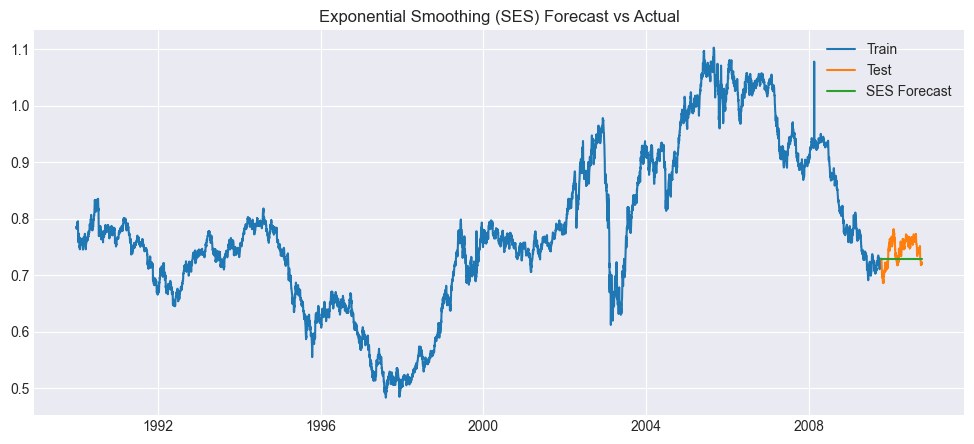

ES model chosen: SES
MAE, RMSE, MAPE: (0.02338748562831542, 0.026228472893545594, np.float64(3.1223394553361365))


In [25]:
best_es_name = sorted(es_results.items(), key=lambda kv: kv[1][1])[0][0]

if best_es_name == "SES":
    best_es_fc = ses_fc.rename("ES_Forecast")
elif best_es_name == "Holt":
    best_es_fc = holt_fc.rename("ES_Forecast")
else:
    best_es_fc = hw_fc.rename("ES_Forecast")

plt.figure(figsize=(12,5))
plt.plot(train["Ex_rate"], label="Train")
plt.plot(test["Ex_rate"], label="Test")
plt.plot(best_es_fc, label=f"{best_es_name} Forecast")
plt.title(f"Exponential Smoothing ({best_es_name}) Forecast vs Actual")
plt.legend()
plt.show()

print("ES model chosen:", best_es_name)
print("MAE, RMSE, MAPE:", es_results[best_es_name])


ARIMA  -> MAE: 0.019518 RMSE: 0.022074 MAPE: 2.6163 %
SES -> MAE: 0.023387 RMSE: 0.026228 MAPE: 3.1223 %


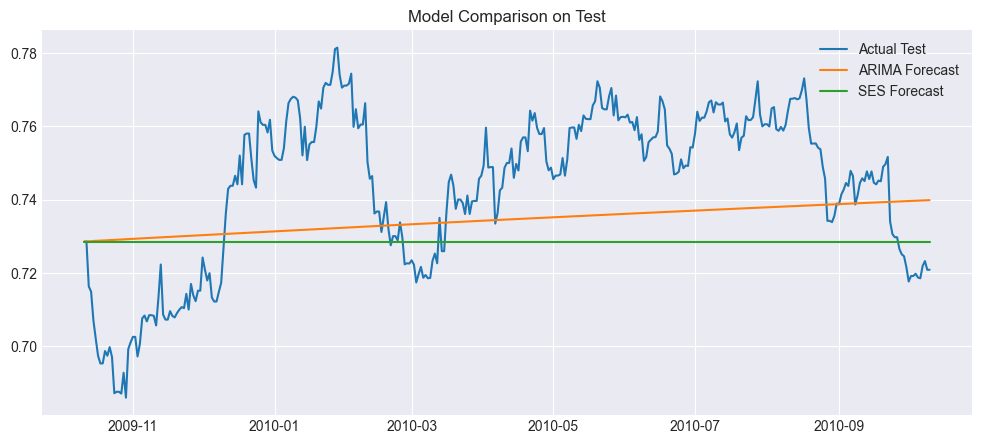

In [26]:
arima_mae, arima_rmse, arima_mape = eval_forecast(test["Ex_rate"], arima_forecast)
es_mae, es_rmse, es_mape = es_results[best_es_name]

print("ARIMA  -> MAE:", round(arima_mae, 6), "RMSE:", round(arima_rmse, 6), "MAPE:", round(arima_mape, 4), "%")
print(best_es_name, "-> MAE:", round(es_mae, 6), "RMSE:", round(es_rmse, 6), "MAPE:", round(es_mape, 4), "%")

plt.figure(figsize=(12,5))
plt.plot(test["Ex_rate"], label="Actual Test")
plt.plot(arima_forecast, label="ARIMA Forecast")
plt.plot(best_es_fc, label=f"{best_es_name} Forecast")
plt.title("Model Comparison on Test")
plt.legend()
plt.show()
